# 14 — Compile XGBoost Results

Compiles the results from XGBoost Experiments 1 to 6.
Analyzes performance improvements of different techniques.

**Prerequisite:** Run Experiments 1-6 first.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = os.path.join('..', 'results')
FIGURES_DIR = os.path.join('..', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print("Compiling XGBoost Results...")

Compiling XGBoost Results...


In [2]:
files = {
    'Baseline': 'experiment1_baseline_xgb.csv',
    'Class Weights': 'experiment2_class_weights_xgb.csv',
    'SMOTE': 'experiment3_smote_xgb.csv',
    'Focal Loss': 'experiment4_focal_loss_xgb.csv',
    'Threshold Opt.': 'experiment5_threshold_xgb.csv',
    'Combined': 'experiment6_combined_xgb.csv'
}

all_dfs = []
for name, filename in files.items():
    path = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.insert(0, 'Technique', name)
        all_dfs.append(df)
    else:
        print(f"WARNING: File {filename} not found.")

if all_dfs:
    xgb_df = pd.concat(all_dfs, ignore_index=True)
    print(xgb_df.to_string(index=False))
else:
    print("ERROR: No results files found.")
    raise FileNotFoundError("Run experiment notebooks first.")

     Technique Version      AUC       F1  Signal_Significance  Train_Time_sec  Best_Threshold
      Baseline       A 0.821946 0.757176           178.668317           20.76             NaN
      Baseline       B 0.811544 0.230017            26.252928          405.88             NaN
      Baseline       C 0.773673 0.018848             3.690886          570.82             NaN
 Class Weights       A 0.821212 0.748854           178.644641          242.52             NaN
 Class Weights       B 0.806582 0.373875            26.053977          608.96             NaN
 Class Weights       C 0.749604 0.150767             5.388093          569.89             NaN
         SMOTE       A 0.821135 0.750783           178.878019          734.38             NaN
         SMOTE       B 0.761019 0.340442            24.546807          630.65             NaN
         SMOTE       C 0.709420 0.116152             4.626338          446.96             NaN
    Focal Loss       A 0.818397 0.767759           170.93537

In [3]:
# Generate pivot tables for each metric
for metric in ['AUC', 'F1', 'Signal_Significance']:
    pivot = xgb_df.pivot(index='Technique', columns='Version', values=metric)
    print(f"\n--- XGBoost {metric} Comparison ---")
    print(pivot.round(4).to_string())
    pivot.to_csv(os.path.join(RESULTS_DIR, f'xgb_pivot_{metric.lower()}.csv'))


--- XGBoost AUC Comparison ---
Version              A       B       C
Technique                             
Baseline        0.8219  0.8115  0.7737
Class Weights   0.8212  0.8066  0.7496
Combined        0.8205  0.8006  0.7433
Focal Loss      0.8184  0.8112  0.7816
SMOTE           0.8211  0.7610  0.7094
Threshold Opt.  0.8215  0.8068  0.7690

--- XGBoost F1 Comparison ---
Version              A       B       C
Technique                             
Baseline        0.7572  0.2300  0.0188
Class Weights   0.7489  0.3739  0.1508
Combined        0.7693  0.3912  0.1649
Focal Loss      0.7678  0.4037  0.1872
SMOTE           0.7508  0.3404  0.1162
Threshold Opt.  0.7698  0.3983  0.1764

--- XGBoost Signal_Significance Comparison ---
Version                A        B       C
Technique                                
Baseline        178.6683  26.2529  3.6909
Class Weights   178.6446  26.0540  5.3881
Combined        178.5115  25.9188  5.3129
Focal Loss      170.9354  26.9012  5.8263
SMOTE        

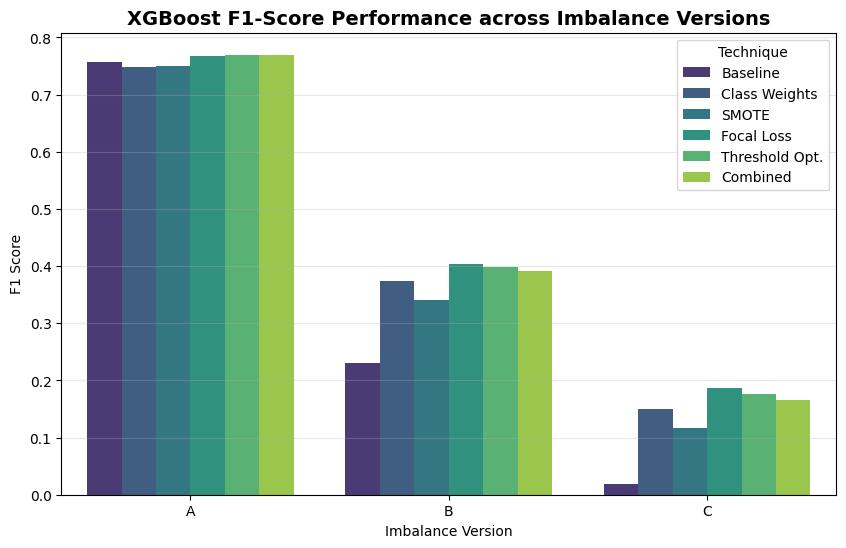

Saved figure: ..\figures\xgb_f1_comparison.png


In [4]:
# Create a bar plot comparing F1 scores across techniques
plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_df, x='Version', y='F1', hue='Technique', palette='viridis')
plt.title('XGBoost F1-Score Performance across Imbalance Versions', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score')
plt.xlabel('Imbalance Version')
plt.grid(axis='y', alpha=0.3)
save_fig = os.path.join(FIGURES_DIR, 'xgb_f1_comparison.png')
plt.savefig(save_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved figure: {save_fig}")